# Chương 3: Trực quan hóa Hiệu năng (Visualization)
Notebook này sử dụng **Python** (`matplotlib`, `pandas`) để vẽ biểu đồ đen trắng chuyên nghiệp, sẵn sàng đưa vào các báo cáo Khoa học/Đồ án tốt nghiệp.
Dữ liệu được lấy từ file `results_time.csv`.

In [5]:
# Import thư viện
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập font và style cơ bản cho biểu đồ chuyên nghiệp
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

csv_file = "../results/results_metrics.csv"
try:
    df = pd.read_csv(csv_file)
    print("Đã tải thành công số liệu!")
    display(df)
except Exception as e:
    print(f"⚠️ Lỗi đọc file: {e}. Vui lòng chạy Notebook 1 trước!")


Đã tải thành công số liệu!


,MinSup,JuliaTime,JuliaMemMB,SPMFTime,SPMFMemMB
0,0.8,0.467785,168.593679,1.352,162.129387
1,0.7,0.692532,-67.082913,1.405,83.520912
2,0.6,1.192037,-96.817352,1.771,159.687622
3,0.5,1.285545,117.914449,2.010,222.660446
4,0.4,2.954686,8.403180,2.785,243.546295


✅ Đã lưu biểu đồ vào file: ../results/efficiency_plot.png


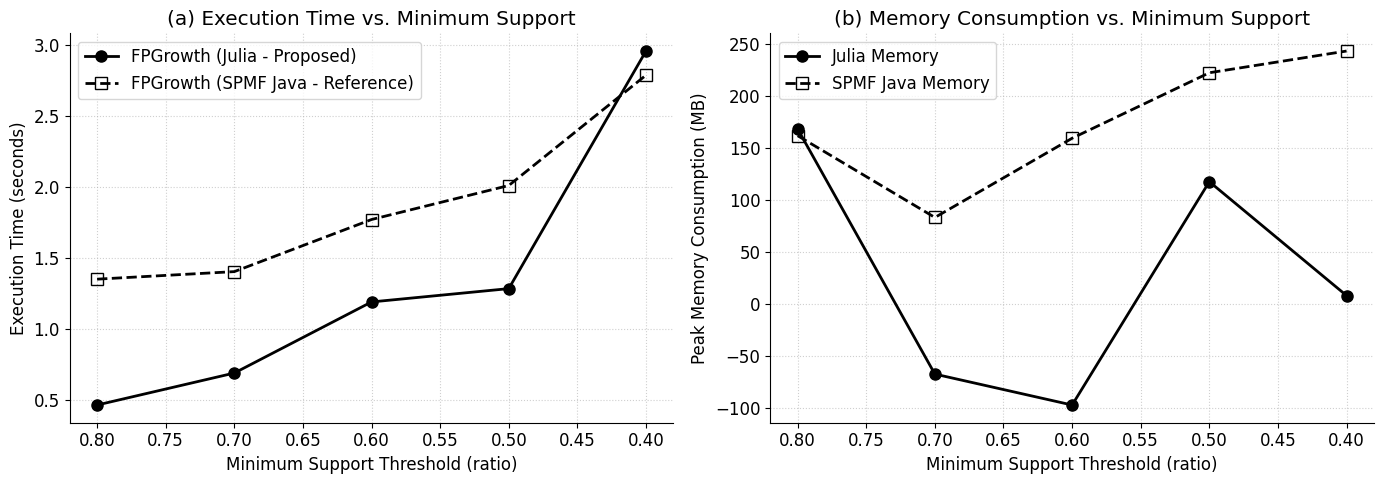

In [6]:
if 'df' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- BIỂU ĐỒ 1: THỜI GIAN THỰC THI (TIME) ---
    # Julia: Đường đen nét liền, marker tròn đặc (-ok)
    # SPMF: Đường đen nét đứt, marker vuông rỗng (--sk, markerfacecolor='none')
    ax1.plot(df['MinSup'], df['JuliaTime'], '-ok', label='FPGrowth (Julia - Proposed)', linewidth=2, markersize=8)
    ax1.plot(df['MinSup'], df['SPMFTime'], '--sk', markerfacecolor='none', label='FPGrowth (SPMF Java - Reference)', linewidth=2, markersize=8)
    
    # Cấu hình trục
    ax1.set_xlabel('Minimum Support Threshold (ratio)')
    ax1.set_ylabel('Execution Time (seconds)')
    ax1.set_title('(a) Execution Time vs. Minimum Support')
    # Đảo ngược trục X (vì min_sup thường vẽ từ lớn về bé thì thời gian tăng dần)
    ax1.invert_xaxis()
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- BIỂU ĐỒ 2: BỘ NHỚ (MEMORY) ---
    ax2.plot(df['MinSup'], df['JuliaMemMB'], '-ok', label='Julia Memory', linewidth=2, markersize=8)
    ax2.plot(df['MinSup'], df['SPMFMemMB'], '--sk', markerfacecolor='none', label='SPMF Java Memory', linewidth=2, markersize=8)
    
    ax2.set_xlabel('Minimum Support Threshold (ratio)')
    ax2.set_ylabel('Peak Memory Consumption (MB)')
    ax2.set_title('(b) Memory Consumption vs. Minimum Support')
    ax2.invert_xaxis()
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    
    # Lưu file chất lượng cao (DPI 300)
    plt.savefig('../results/efficiency_plot.png', dpi=300, bbox_inches='tight')
    print("✅ Đã lưu biểu đồ vào file: ../results/efficiency_plot.png")
    
    plt.show()
